# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Lab assignment №1, part 2
## Gradient boosting on temporal data and feature importances

Today we will work with Gradient Boosting library. It is one of the most popular models these days that shows both great quality and performance.

Choises for library are:

* [LightGBM](https://github.com/Microsoft/LightGBM) by Microsoft. Handful and fast.
* [Catboost](https://github.com/catboost/catboost) by Yandex. Tuned to deal well with categorical features.
* [xgboost](https://github.com/dmlc/xgboost) by dlmc. The most famous framework which got very popular on kaggle.

**Dataset**

By default we will work with widely known [Human Actividy Recognition (HAR) dataset](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones). Data is available at UCI repository.

There are available both raw and preprocessed datasets. This time we will use the preprocessed one.
Some simple preprocessing is done for you.

If you want more interpretable data, you can take [Wine quality dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) (see details below).

Your __ultimate target is to get familiar with one of the frameworks above__ and achieve at least 90% accuracy on test dataset and try to get some useful insights on the features the model paid attention to.

_Despite the main language of this notebook is English, feel free to write your thoughts in Russian._

## Part 0. Downloading and preprocessing

The preprocessing is done for you. Let's take a look at the data:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X_train = np.genfromtxt("../X_train.txt")
y_train = np.genfromtxt("../y_train.txt")
print(f"Train set: {X_train.shape}, {y_train.shape}")

X_test = np.genfromtxt("../X_test.txt")
y_test = np.genfromtxt("../y_test.txt")
print(f"Test set: {X_test.shape}, {y_test.shape}")

n_features = X_train.shape[1]

Train set: (7352, 561), (7352,)
Test set: (2947, 561), (2947,)


In [4]:
activity_labels = {}
with open("../activity_labels.txt", "r") as file:
    for line in file:
        label, name = line.strip().split(" ")
        activity_labels[int(label)] = name

activity_labels

{1: 'WALKING',
 2: 'WALKING_UPSTAIRS',
 3: 'WALKING_DOWNSTAIRS',
 4: 'SITTING',
 5: 'STANDING',
 6: 'LAYING'}

Let's normalize data

In [5]:
data_mean = X_train.mean(axis=0)
data_std = X_train.std(axis=0)

X_train = (X_train - data_mean) / data_std
X_test = (X_test - data_mean) / data_std

The dataset has some duplicating features. Let's remove them

In [6]:
# fmt: off
duplicating_columns = (
    205, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 231, 244, 257, 507, 520, 533, 546,
)
# fmt: on

duplicating_mask = np.isin(range(n_features), duplicating_columns)

In [7]:
X_train_unique = X_train[:, ~duplicating_mask]
X_test_unique = X_test[:, ~duplicating_mask]

X_train_unique.shape, X_test_unique.shape

((7352, 540), (2947, 540))

PCA could be useful in this case. E.g.

In [8]:
from sklearn.decomposition import PCA

In [9]:
pca = PCA(0.99)

X_train_pca = pca.fit_transform(X_train_unique)
X_test_pca = pca.transform(X_test_unique)

X_train_pca.shape, X_test_pca.shape

((7352, 179), (2947, 179))

Text(0, 0.5, 'Principal component 2')

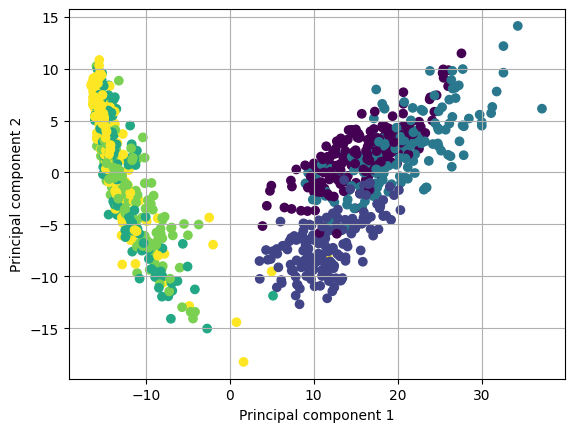

In [13]:
plt.scatter(X_train_pca[:1000, 0], X_train_pca[:1000, 1], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")

Text(0, 0.5, 'Principal component 5')

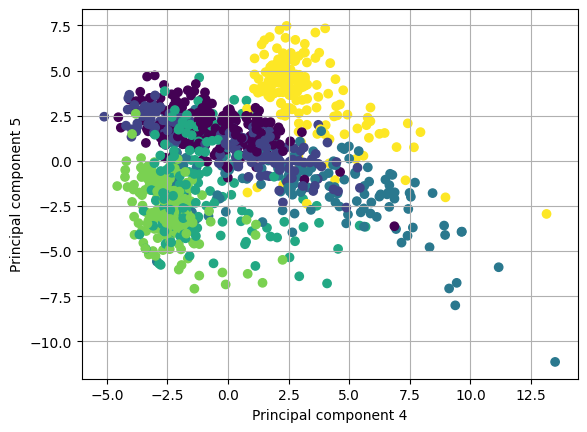

In [14]:
plt.scatter(X_train_pca[:1000, 3], X_train_pca[:1000, 4], c=y_train[:1000])
plt.grid()
plt.xlabel("Principal component 4")
plt.ylabel("Principal component 5")

## Part 1. Fit the model.

Despite optimal parameters (e.g. for xgboost) can be found on the web, we still want you to approximate them by yourself.

In this part just check some (3-5) sets of hyperparameters by hand.

##### Мы, в идеале, должны работать с тремя выборками: тренировочной, тестовой и валидационной. Но, опять же, мы не в проде, а просто знакомимся с фреймворками, поэтому я на это ЗАБИЛ. А ещё lightgbm почему-то хочет работать с метками классов от 0 до 5, а не с 1 до 6. Давайте поправим:

In [14]:
y_train = y_train - 1
y_test = y_test - 1

In [30]:
# YOUR CODE HERE

import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report

train_data = lgb.Dataset(X_train_pca, label=y_train)
test_data = lgb.Dataset(X_test_pca, label=y_test, reference=train_data)

# Здесь мы определяем функцию, которая берёт параметры, выборки и учит модель:
def train_evaluate(params, train_data, test_data, early_stopping_rounds=10):
    
    early_stopping_callback = lgb.early_stopping(stopping_rounds=early_stopping_rounds)
    model = lgb.train(params, train_data, valid_sets=[test_data], callbacks=[early_stopping_callback])
    
    y_pred = model.predict(X_test_pca, num_iteration=model.best_iteration)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    accuracy = accuracy_score(y_test, y_pred_classes)
    print(f"Accuracy: {accuracy}")
    
    report = classification_report(y_test, y_pred_classes)
    print(report)
    
    return accuracy

# Это наши взятые наугад гиперпараметры:
hyperparams_list = [
    {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.1, 'num_leaves': 30, 'n_estimators': 50, 'max_depth': -1, 'reg_alpha': 0.0},
    {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.05, 'num_leaves': 40, 'min_data_in_leaf': 20, 'n_estimators': 100, 'max_depth': 10, 'reg_alpha': 0.1},
    {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.01, 'num_leaves': 50, 'min_data_in_leaf': 10, 'n_estimators': 150, 'max_depth': 15, 'reg_alpha': 0.2},
    {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.1, 'num_leaves': 20, 'min_data_in_leaf': 30, 'n_estimators': 200, 'max_depth': 7, 'reg_alpha': 0.0},
    {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.05, 'num_leaves': 60, 'min_data_in_leaf': 15, 'n_estimators': 250, 'max_depth': 12, 'reg_alpha': 0.05},
]

# Получаем результаты:
results = {}
for i, params in enumerate(hyperparams_list):
    print(f"\nEvaluating hyperparameters set {i+1}: {params}")
    params["feature_pre_filter"] = False
    accuracy = train_evaluate(params, train_data, test_data)
    results[f"set_{i+1}"] = accuracy

# Печатаем результаты:
print("\nResults:")
for key, value in results.items():
    print(f"{key}: {value}")

# Example: https://rpubs.com/burakh/har_xgb


Evaluating hyperparameters set 1: {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.1, 'num_leaves': 30, 'n_estimators': 50, 'max_depth': -1, 'reg_alpha': 0.0}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45645
[LightGBM] [Info] Number of data points in the train set: 7352, number of used features: 179
[LightGBM] [Info] Start training from score -1.791216
[LightGBM] [Info] Start training from score -1.924514
[LightGBM] [Info] Start training from score -2.009071
[LightGBM] [Info] Start training from score -1.743436
[LightGBM] [Info] Start training from score -1.677246
[LightGBM] [Info] Start training from score -1.653513
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's multi_logloss: 0.274193
Accuracy: 0.8968442483881914
        

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


Early stopping, best iteration is:
[73]	valid_0's multi_logloss: 0.251772
Accuracy: 0.9063454360366474
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91       496
         1.0       0.90      0.94      0.92       471
         2.0       0.93      0.75      0.83       420
         3.0       0.89      0.85      0.87       491
         4.0       0.87      0.93      0.90       532
         5.0       1.00      0.96      0.98       537

    accuracy                           0.91      2947
   macro avg       0.91      0.90      0.90      2947
weighted avg       0.91      0.91      0.91      2947


Evaluating hyperparameters set 5: {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': 0.05, 'num_leaves': 60, 'min_data_in_leaf': 15, 'n_estimators': 250, 'max_depth': 12, 'reg_alpha': 0.05}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010995 seconds.
You can set `force_col

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

##### Есть варнинги, они говорят, что я два раза указал один и тот же параметр (упс), но ничего страшного, значение, которое в итоге используется -- правильное.

## Part 2. Use hyper parameter tuning system

Use [optuna](https://optuna.org/), [hyperopt](http://hyperopt.github.io/hyperopt/) or any other zero order optimizer to find optimal hyper param set.

In [32]:
# YOUR CODE HERE
import optuna

# Функция берёт trial из optuna и возвращает accuracy
def objective(trial):
    learning_rate = trial.suggest_float("learning_rate", 0, 0.2)
    num_leaves = trial.suggest_int("num_leaves", 20, 60)
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 5, 15)
    reg_alpha = trial.suggest_float("reg_alpha", 0.0, 0.2)
    params = {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6, 'learning_rate': learning_rate, 'num_leaves': num_leaves, 'n_estimators': n_estimators, 'max_depth': max_depth, 'reg_alpha': reg_alpha}
    accuracy = train_evaluate(params, train_data, test_data)
    return accuracy

# Даём optuna проявить себя:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

[I 2024-11-24 15:07:53,359] A new study created in memory with name: no-name-e29bc13f-d78f-4f09-8c87-eed5b2a87d70


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020888 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45645
[LightGBM] [Info] Number of data points in the train set: 7352, number of used features: 179
[LightGBM] [Info] Start training from score -1.791216
[LightGBM] [Info] Start training from score -1.924514
[LightGBM] [Info] Start training from score -2.009071
[LightGBM] [Info] Start training from score -1.743436
[LightGBM] [Info] Start training from score -1.677246
[LightGBM] [Info] Start training from score -1.653513
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[70]	valid_0's multi_logloss: 0.391184


[I 2024-11-24 15:08:02,048] Trial 0 finished with value: 0.8788598574821853 and parameters: {'learning_rate': 0.029138264019300954, 'num_leaves': 27, 'n_estimators': 70, 'max_depth': 12, 'reg_alpha': 0.04796793492279532}. Best is trial 0 with value: 0.8788598574821853.


Accuracy: 0.8788598574821853
              precision    recall  f1-score   support

         0.0       0.80      0.95      0.87       496
         1.0       0.89      0.90      0.90       471
         2.0       0.90      0.68      0.78       420
         3.0       0.86      0.81      0.84       491
         4.0       0.85      0.93      0.89       532
         5.0       0.99      0.95      0.97       537

    accuracy                           0.88      2947
   macro avg       0.88      0.87      0.87      2947
weighted avg       0.88      0.88      0.88      2947

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013005 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45645
[LightGBM] [Info] Number of data points in the train set: 7352, number of used features: 179
[LightGBM] [Info] Start training from score -1.791216
[LightGBM] [Info] Start training from score -1.924514
[LightGBM] [Info] Start traini

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


...

Accuracy: 0.9175432643366135
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92       496
         1.0       0.90      0.94      0.92       471
         2.0       0.94      0.77      0.85       420
         3.0       0.92      0.87      0.89       491
         4.0       0.89      0.95      0.92       532
         5.0       1.00      0.97      0.98       537

    accuracy                           0.92      2947
   macro avg       0.92      0.91      0.91      2947
weighted avg       0.92      0.92      0.92      2947

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45645
[LightGBM] [Info] Number of data points in the train set: 7352, number of used features: 179
[LightGBM] [Info] Start training from score -1.791216
[LightGBM] [Info] Start training from score -1.924514
[LightGBM] [Info] Start traini

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

[I 2024-11-24 15:22:03,521] Trial 99 finished with value: 0.9161859518154055 and parameters: {'learning_rate': 0.13177519008164393, 'num_leaves': 57, 'n_estimators': 285, 'max_depth': 6, 'reg_alpha': 0.1999220569375004}. Best is trial 94 with value: 0.9205972175093315.


Accuracy: 0.9161859518154055
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92       496
         1.0       0.91      0.94      0.92       471
         2.0       0.93      0.78      0.85       420
         3.0       0.91      0.87      0.89       491
         4.0       0.88      0.94      0.91       532
         5.0       1.00      0.97      0.98       537

    accuracy                           0.92      2947
   macro avg       0.92      0.91      0.91      2947
weighted avg       0.92      0.92      0.92      2947


### Conclusion

Please, write down your thoughts on the experiment results:

...

In [36]:
print("Best trial: ", study.best_trial.number)
trial = study.best_trial

print(f"Accuracy: {np.round(trial.value, 3)}")
print("Best hyperparameters: ", trial.params)

Best trial:  94
Accuracy: 0.921
Best hyperparameters:  {'learning_rate': 0.1353988118762108, 'num_leaves': 59, 'n_estimators': 295, 'max_depth': 5, 'reg_alpha': 0.17446131373351645}


##### Лучшее значение параметров, которое я подобрал руками, давало accuracy 0.906, конечно, за 100 попыток, optuna подобрал получше: 0.921. Разница (наверное) была бы ещё заметнее, если бы я честно сделал валидационную выборку. Ещё, кажется, что неглубокие деревья с "основательной" регуляризацией и большим количеством итераций бустинга в данном конкретном случае оказались наилучшими

## Part 3. Interpret the model predictions

Please use [shap](https://github.com/slundberg/shap) to build some plots and try to interpret them.

##### Нужно перезагрузить ноутбук, shap требует другую версию numpy... Сохраню модель и загружу её после перезагрузки

In [51]:
early_stopping_callback = lgb.early_stopping(stopping_rounds=10)
params = {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 6}
for p in study.best_trial.params:
    params[p] = study.best_trial.params[p]
model = lgb.train(params, train_data, valid_sets=[test_data], callbacks=[early_stopping_callback])
model.save_model("lgb_best_model.txt")

C:\Users\serge\Desktop\ML_course\.venv\Lib\site-packages\lightgbm\engine.py:204: UserWarning: Found `n_estimators` in params. Will use it instead of argument
  _log_warning(f"Found `{alias}` in params. Will use it instead of argument")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 45645
[LightGBM] [Info] Number of data points in the train set: 7352, number of used features: 179
[LightGBM] [Info] Start training from score -1.791216
[LightGBM] [Info] Start training from score -1.924514
[LightGBM] [Info] Start training from score -2.009071
[LightGBM] [Info] Start training from score -1.743436
[LightGBM] [Info] Start training from score -1.677246
[LightGBM] [Info] Start training from score -1.653513
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] 

In [52]:
model.save_model("lgb_model.txt")

In [10]:
import lightgbm as lgb

model = lgb.Booster(model_file="lgb_best_model.txt")

In [11]:
import shap# noqa: F401


# YOUR CODE HERE

# Теперь используем всю мощь shap:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_pca)

In [28]:
shap_values.shape

(2947, 179, 6)

In [26]:
X_test_pca.shape

(2947, 179)

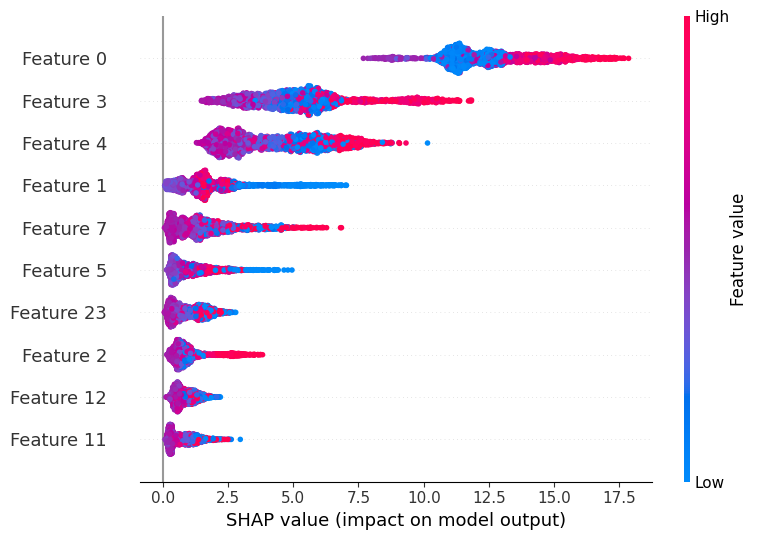

In [31]:
shap.summary_plot(np.sum(np.abs(shap_values), axis=-1), X_test_pca, max_display=10)

### Conclusion

Your thoughts about the plots and model behaviour:

...

##### Немного жаль, что у нас бессмысленные названия фичей, иначе интерпретировать было бы проще. Из общего графика мы видим, что SHAP по модулю самый большой (после усреднения по классам) у 0-ой фичи, с достаточно большим отрывом. Она наиболее важна и сильнее всего влияет на предсказание. Далее, первые 10 по "важности" фичей изображены на графике сверху вниз. Также видно, что наибольший вклад в предсказание делает 0-ая фича, если принимает большие значения, а маленькие значения учитываются моделью в меньшей степени. То же самое справедливо и для 3-ей фичи, а вот для 1-ой фичи всё наоборот: маленькие значения вносят больший вклад (имеют SHAP value выше по модулю). Чтобы посмотреть на то, в какую сторону каждая из фичей толкает предсказание (для каждого отдельного класса), нужно строить другой график:

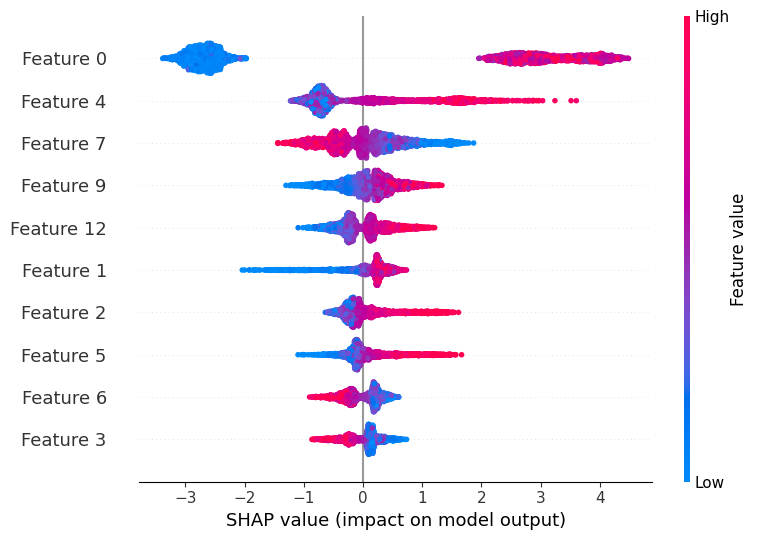

In [32]:
shap.summary_plot(shap_values[:, :, 0], X_test_pca, max_display=10)

##### Теперь нам виден и знак SHAP value для 0-ого класса, и некоторые специфические особенности влияния значений фичей на предсказание именно 0-ого класса. Для этого класса, например, 3-я фича не так важна, как в среднем. Теперь мы также видим, что большие значения 0-ой фичи поднимают вероятность для объекта оказаться в 0-ом классе, а маленькие -- тоже сильно влияют на вероятность, но уже уменьшают её. Ну а вообще, можно сделать много разных наблюдений...